# Convolutional Neural Network - CNN

## Importing libraries

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

## Loading Saved Data

In [2]:
X_train = np.load('../data/processed/X_train.npy')
X_val = np.load('../data/processed/X_val.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_val = np.load('../data/processed/y_val.npy')
y_test = np.load('../data/processed/y_test.npy')

print(X_train.shape, y_train.shape)

(43073, 64, 64, 3) (43073,)


## Data Augmentation

In [3]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), #randomly flips images left-right and/or top-bottom during training
    layers.RandomRotation(0.5), #randomly rotates images by up to 0.5 × 2π radians (i.e., up to 180 degrees) during training
])

## Building the CNN

In [4]:
model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    data_augmentation,

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,339 (4.36 MB)

 Trainable params: 1,142,339 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training with EarlyStopping

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

## Evaluating on test Set

In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## Plotting CNN's Training Curve

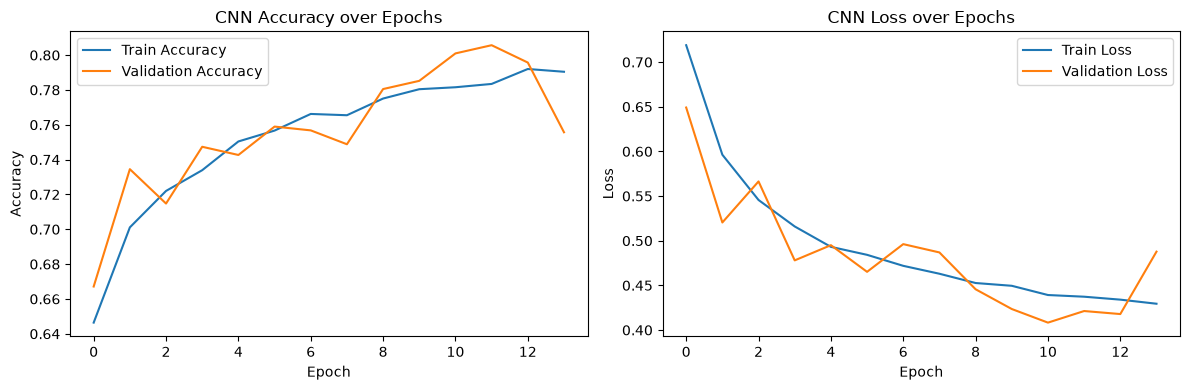

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/cnn_training_curves.png')
plt.show()

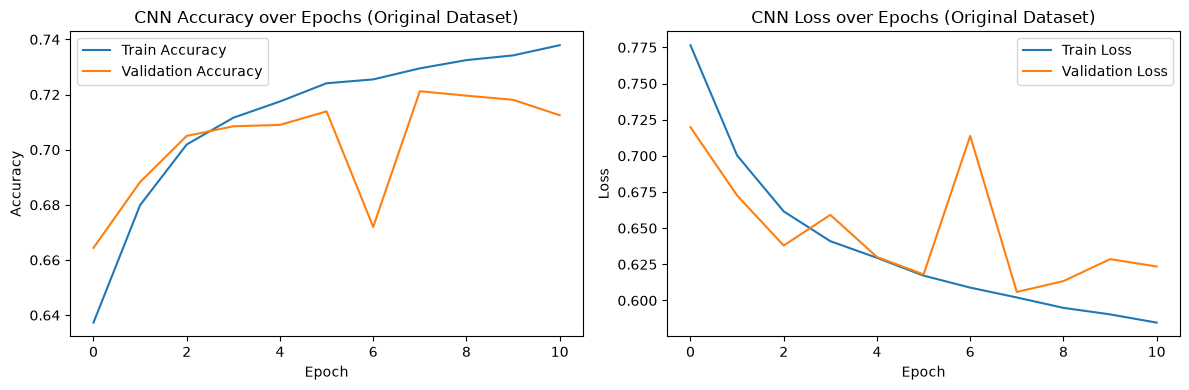

In [10]:
import matplotlib.pyplot as plt

original_train_acc = [0.6373, 0.6799, 0.7019, 0.7116, 0.7175,
                      0.7241, 0.7255, 0.7295, 0.7325, 0.7342, 0.7379]
original_val_acc = [0.6644, 0.6883, 0.7050, 0.7085, 0.7090,
                    0.7139, 0.6720, 0.7212, 0.7196, 0.7181, 0.7125]
original_train_loss = [0.7765, 0.7003, 0.6616, 0.6410, 0.6295,
                       0.6172, 0.6089, 0.6021, 0.5949, 0.5904, 0.5847]
original_val_loss = [0.7198, 0.6726, 0.6380, 0.6592, 0.6301,
                     0.6180, 0.7138, 0.6059, 0.6134, 0.6286, 0.6235]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(original_train_acc, label='Train Accuracy')
axes[0].plot(original_val_acc, label='Validation Accuracy')
axes[0].set_title('CNN Accuracy over Epochs (Original Dataset)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(original_train_loss, label='Train Loss')
axes[1].plot(original_val_loss, label='Validation Loss')
axes[1].set_title('CNN Loss over Epochs (Original Dataset)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/cnn_training_curves.png')
plt.show()

## Part 2: CNN with Confidence Filtering + Class Weighting

The original CNN (Part 1) was trained on all 61,534 galaxies using a simple 0.5
vote-fraction threshold for labeling. Two known issues with that setup:

1. **Noisy labels** — galaxies where only 51% of volunteers agreed on a class
   got the same clean label as ones where 95% agreed. The model learned from
   genuinely ambiguous examples as if they were certain.

2. **Class imbalance** — Spiral galaxies made up only ~17% of the training set,
   so the model was implicitly biased toward Smooth and Irregular.

This section retrains the same CNN architecture with both issues addressed:
- **Confidence filtering** — only galaxies where the winning vote fraction is
  >= 0.7 are kept (36,812 out of 61,578 original, ~60%). The 40% dropped were
  genuinely ambiguous even to human volunteers.
- **Class weighting** — the loss function is weighted so Spiral misclassifications
  are penalized more heavily, forcing the model to learn that class properly
  despite having fewer examples.

Everything else stays identical to Part 1 (same architecture, same augmentation,
same early stopping) so the comparison is clean — the only variables that changed
are the data quality and the loss weighting.

## Loading Confident Arrays

In [1]:
import numpy as np

X_train = np.load('../data/processed/X_train_conf.npy')
X_val = np.load('../data/processed/X_val_conf.npy')
X_test = np.load('../data/processed/X_test_conf.npy')
y_train = np.load('../data/processed/y_train_conf.npy')
y_val = np.load('../data/processed/y_val_conf.npy')
y_test = np.load('../data/processed/y_test_conf.npy')

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (25768, 64, 64, 3), Val: (5522, 64, 64, 3), Test: (5522, 64, 64, 3)


## Class Weights

In [2]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {np.int64(0): np.float64(0.7596474160549512), np.int64(1): np.float64(0.867434188379452), np.int64(2): np.float64(1.8840388974190247)}


## Rebuilding CNN Model and Training it On new Class Weights

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.5),
])

model = keras.Sequential([
    layers.Input(shape=(64, 64, 3)),
    data_augmentation,
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

Epoch 1/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 83s 97ms/step - accuracy: 0.6464 - loss: 0.7189 - val_accuracy: 0.6671 - val_loss: 0.6491
Epoch 2/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 91s 113ms/step - accuracy: 0.7011 - loss: 0.5963 - val_accuracy: 0.7345 - val_loss: 0.5204
Epoch 3/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 94s 117ms/step - accuracy: 0.7220 - loss: 0.5456 - val_accuracy: 0.7148 - val_loss: 0.5664
Epoch 4/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 99s 123ms/step - accuracy: 0.7339 - loss: 0.5160 - val_accuracy: 0.7474 - val_loss: 0.4780
Epoch 5/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 93s 116ms/step - accuracy: 0.7504 - loss: 0.4931 - val_accuracy: 0.7427 - val_loss: 0.4950
Epoch 6/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 91s 112ms/step - accuracy: 0.7567 - loss: 0.4842 - val_accuracy: 0.7590 - val_loss: 0.4652
Epoch 7/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 91s 113ms/step - accuracy: 0.7662 - loss: 0.4719 - val_accuracy: 0.7568 - val_loss: 0.4962
Epoch 8/20
806/806 ━━━━━━━━━━━━━━━━━━━━ 97s 120ms/step - accuracy: 0.7655 - loss: 0.

## Evaluating on test Set

In [4]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.8013 - loss: 0.4143
Test Loss: 0.4143
Test Accuracy: 0.8013


## Plotting CNN's Training Curve

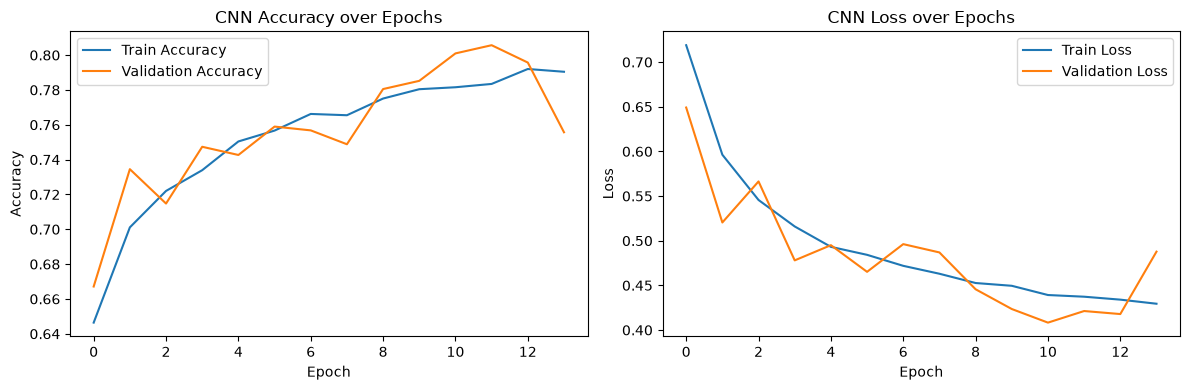

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('CNN Accuracy over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('CNN Loss over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/cnn_training_curves.png')
plt.show()

## Plotting a Comparison Plot

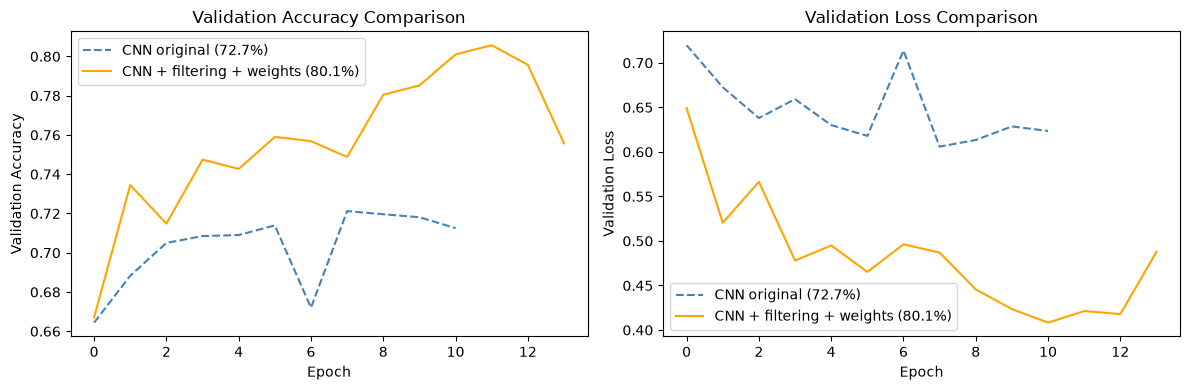

In [11]:
confident_val_acc = [0.6671, 0.7345, 0.7148, 0.7474, 0.7427,
                     0.7590, 0.7568, 0.7488, 0.7805, 0.7852, 0.8010, 0.8057, 0.7957, 0.7557]
confident_val_loss = [0.6491, 0.5204, 0.5664, 0.4780, 0.4950,
                      0.4652, 0.4962, 0.4869, 0.4456, 0.4235, 0.4083, 0.4213, 0.4179, 0.4878]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(original_val_acc, label='CNN original (72.7%)', linestyle='--', color='steelblue')
axes[0].plot(confident_val_acc, label='CNN + filtering + weights (80.1%)', color='orange')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()

axes[1].plot(original_val_loss, label='CNN original (72.7%)', linestyle='--', color='steelblue')
axes[1].plot(confident_val_loss, label='CNN + filtering + weights (80.1%)', color='orange')
axes[1].set_title('Validation Loss Comparison')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/cnn_comparison_curves.png')
plt.show()

## Saving the model

In [ ]:
model.save('../models/cnn_confident.keras')